In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import dump, load

from xai_aux import CFCalculations

import os

In [2]:
pd.set_option("display.max_columns", 99)

In [3]:
def get_distance(A,B, continuous_columns, categorical_columns, l_norm=2):
    
    combined = np.vstack((A, B))
    
    stds = np.std(combined[:, categorical_columns], axis=0)
    epsilon = 1e-8
    adjusted_stds = np.where(stds == 0, epsilon, stds) 

    weights_categorical = 1.48 / adjusted_stds
    mads = np.median(np.abs(combined[:, continuous_columns] - 
                            np.median(combined[:, continuous_columns], axis=0)), axis=0)
    adjusted_mads = np.where(mads == 0, epsilon, mads) 
    weights_continuous = 1 / adjusted_mads

    # Combine weights
    weights = np.zeros(combined.shape[1])
    weights[categorical_columns] = weights_categorical
    weights[continuous_columns] = weights_continuous

    # Compute weighted L2 distances for same-index pairs
    differences = A - B  # Element-wise differences
    weighted_differences = differences * weights  # Apply weights element-wise
    l_distances = np.linalg.norm(weighted_differences, axis=1, ord=l_norm)
    return l_distances

In [4]:
l_order = 1
cm = ['TP','FP','FN','TN']

colours = {('lr', 'skl'): 'deepskyblue', 
           ('lr', 'blr_marg'): 'blue', 
           ('lr', 'blr_mean'): 'lightblue',
           ('lr', 'nice'): 'magenta',
           ('lr', 'dice'): 'hotpink', 
           ('lr', 'RL'): 'lavender',
           ('rf', 'nice'): 'darkorange',
           ('rf', 'dice'): 'orange',
           ('rf', 'RL'): 'palegoldenrod',
           ('tf', 'nice'): 'darkgreen', 
           ('tf', 'dice'): 'lightgreen'
           }

In [5]:
def load_dataset(dataset_name, variant="standard"):
    """
    Load only the requested dataset variant.
    
    Parameters:
        dataset_name (str): Name of the dataset (e.g., "mock_data_3", "gsc", etc.).
        variant (str): One of ["standard", "noniid_test", "ommited_var_test"].
    
    Returns:
        dict: Loaded dataset components.
    """
    base_path = f"data/{dataset_name}"
    
    # Validate variant
    if variant not in ["standard", "noniid_test", "ommited_var_test"]:
        raise ValueError(f"Unknown variant: {variant}")

    # Special handling for mock datasets
    if dataset_name.startswith("mock_data"):
        mock_num = dataset_name[-1]
        
        # Only mock_data_3 supports extra variants
        if variant in ["noniid_test", "ommited_var_test"] and mock_num != "3":
            raise ValueError(f"{variant} is only available for mock_data_3")

    # Define paths based on the variant
    if variant == "standard":
        dataset_path = f"{base_path}_cf_results_dict.pkl"
        model_results_path = f"{base_path}_model_results.pkl"
        cfs_good_indices_path = f"{base_path}_cfs_good_indices.pkl"
        cf_calc_paths = [f"{base_path}_{i}.pkl" for i in range(11)]
    else:
        dataset_path = f"{base_path}_{variant}_cf_results_dict.pkl"
        model_results_path = f"{base_path}_{variant}_model_results.pkl"
        cfs_good_indices_path = f"{base_path}_{variant}_cfs_good_indices.pkl"
        cf_calc_paths = [f"{base_path}_{variant}{i}.pkl" for i in range(11)]

    # Load only the requested dataset
    return {
        "cf_results_dict": load(dataset_path),
        "cf_calc": [load(path) for path in cf_calc_paths],
        "model_results_dict": load(model_results_path),
        "cfs_good_indices": load(cfs_good_indices_path),
    }

In [6]:
# # Choose dataset dynamically
# dataset_name = "mock_data"  # Options: "mock_data", "german_credit", "adult_income", "gsc"
# mock_data = 3  # Only relevant if dataset_name == "mock_data"
# data = load_dataset(dataset_name, mock_data if dataset_name == "mock_data" else None)

data = load_dataset("mock_data1", variant="standard") # "ommited_var_test" "noniid_test" "standard"

# Extract variables
cf_results_dict = data["cf_results_dict"]
cf_calc = data["cf_calc"]
model_results_dict = data["model_results_dict"]
cfs_good_indices = data["cfs_good_indices"]

In [7]:
noises_list = list(cf_results_dict.keys())[1:]
cf_methods = list(cf_results_dict[noises_list[0]].keys())
n_features = np.array(cf_results_dict['noise_0'][('lr','nice')]).shape[1]
numerical_columns = [int(i) for i in cf_calc[0].num_cols_tf]
categorical_columns = [int(i) for i in cf_calc[0].cat_cols_tf]

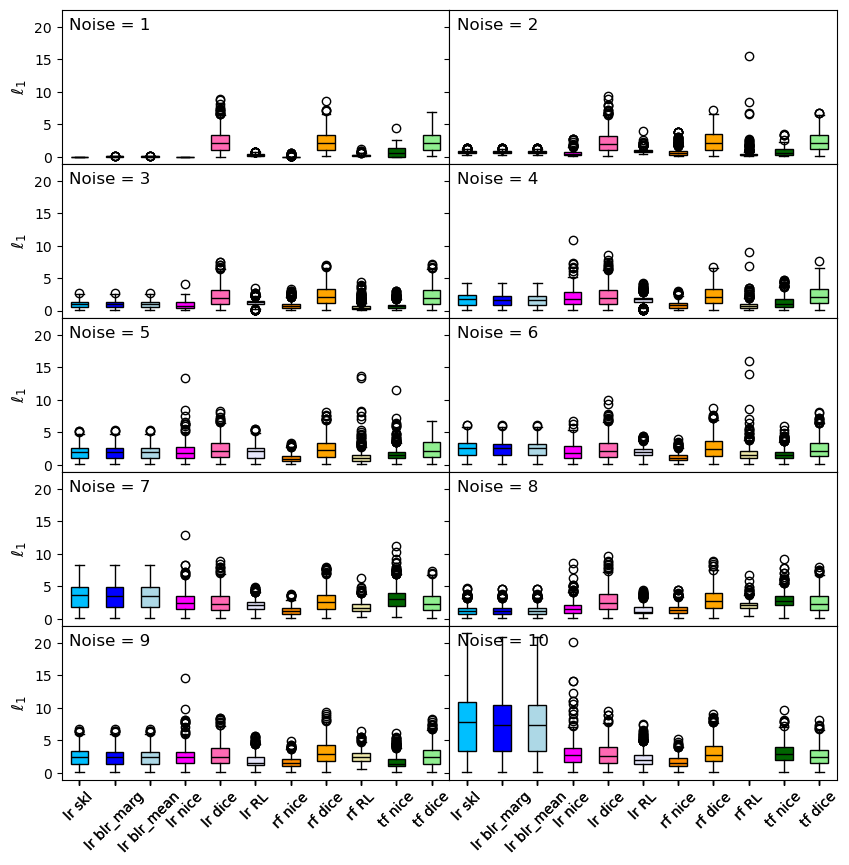

In [8]:
n_rows, n_cols = 5, 2  # Define explicitly to be adaptable
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    d2 = []
    labels = []
    colour_list = []
    
    # Define the total number of labels expected (assuming 11 methods)
    expected_labels = [k[0] + ' ' + k[1] for k in cf_methods]  # All possible labels
    expected_d2 = {label: [] for label in expected_labels}  # Dictionary to store distances

    for k in cf_methods:
        colour_list.append(colours[k])
        A = cf_results_dict[noises_list[i]][k]
        B = cf_results_dict['noise_0'][k]

        if k[1] in {'nice', 'dice', 'RL'} and k[0] != 'tf':
            A = cf_calc[i].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[i].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)

        good_indices = cfs_good_indices[noises_list[i]][k]
        
        if sum(good_indices) / len(good_indices) > 0.9:
            expected_d2[k[0] + ' ' + k[1]] = get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=l_order)

    # Ensure that all expected labels appear, even if they have no data points
    d2 = list(expected_d2.values())  # Boxplot data (some lists will be empty)
    labels = list(expected_d2.keys())  # Ensure all labels appear

    # Apply x-labels only for the last row
    if i // n_cols == n_rows - 1:
        bplot = ax.boxplot(d2, tick_labels=labels, widths=0.5, patch_artist=True)
    else:
        bplot = ax.boxplot(d2, tick_labels=['' for _ in labels], widths=0.5, patch_artist=True)

    #ax.set_ylim([0, 100])

    for patch, color in zip(bplot['boxes'], colour_list):
        patch.set_facecolor(color)
    for median in bplot['medians']:
        median.set_color('black')

    ax.text(0.02, 0.95, 'Noise = ' + noises_list[i][6:9], fontsize=12,
            verticalalignment='top', horizontalalignment='left',
            transform=ax.transAxes)
    
    # Set y-labels for leftmost column
    if i % n_cols == 0:
        ax.set_ylabel(r'$\ell_1$', fontsize=12, fontweight='bold')

    ax.tick_params(axis='x', labelrotation=45)

fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero


In [9]:
cf_calc[ii]

NameError: name 'ii' is not defined

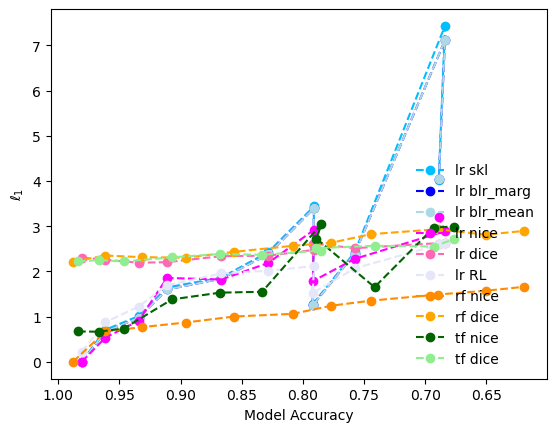

In [ ]:
for i, kk in enumerate(cf_methods):
    x_acc = []
    d2 = []
    compl = {}
    for k in cf_results_dict:
        if k=='noise_0': continue
        ii = int(k.split("_")[-1])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]
        if kk[1]=='nice' or kk[1]=='dice' or kk[1]=='RL':
            if kk[0]!='tf':
                A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
                B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
        good_indices = cfs_good_indices[k][kk]
        d_temp = get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=l_order)

        if len(d_temp>0):
            d2.append(d_temp)
            compl[(kk, k)] = (sum(good_indices)/len(good_indices))
            x_acc.append(model_results_dict[k][(kk[0],'accuracy')])
        
    d2 = np.array([np.array([np.mean(i),np.percentile(i,25), np.percentile(i,75)])  for i in d2])

    if len(d2)==0: continue

    if any(value < 0.9 for value in compl.values()):
        pass
    else:
        plt.plot(x_acc, d2[:,0], color=colours[kk],label=kk[0]+' '+kk[1],alpha=1, linestyle='--', marker='o')
        #plt.fill_between(x_acc, d2[:,1], d2[:, 2], color=colours[kk],alpha=0.2)
plt.legend(frameon=False,loc='lower right')
plt.ylabel(r'$\ell_1$')
plt.xlabel('Model Accuracy')
plt.gca().invert_xaxis()

In [ ]:
def model_dict_to_df(model_dict):
    df = pd.DataFrame.from_dict(model_dict, orient='index', columns=['value'])
    df.index = pd.MultiIndex.from_tuples(df.index, names=['model', 'metric'])
    df = df.unstack(level=1)
    df.columns = df.columns.droplevel(1)
    df = df.reset_index()
    df.columns = ['model','accuracy', 'precision']
    return df

In [ ]:
methods2 = ['R19', 'BR19 (Mean)', 'BR19 (Marg)', 'DiCE', 'NICE', 'RL']
d2 = {'R19':[('lr', 'skl')], 
      'BR19 (Marg)':[('lr', 'blr_marg')], 
      'BR19 (Mean)':[('lr', 'blr_mean')], 
      'DiCE': [('lr', 'dice'), ('rf', 'dice'),('tf', 'dice')],
      'NICE': [('lr', 'nice'), ('rf', 'nice'),('tf', 'dice')],
      'RL': [('lr', 'RL'),('rf', 'RL')]}

In [ ]:
dfs = []
dataset_in = 'mock 1'
for i in model_results_dict:
    df_t = model_dict_to_df(model_results_dict[i])
    df_t.insert(0,'Noise Level',i)
    df_t.insert(0,'Dataset',dataset_in)
    dfs.append(df_t)
df = pd.concat(dfs).reset_index(drop=True) # dfs concatanation here

for j in [i+' Compl' for i in methods2]:
    df[j] = np.nan
for j in [i+' L1' for i in methods2]:
    df[j] = np.nan
for j in [i+' L2' for i in methods2]:
    df[j] = np.nan
    
for noise in list(cf_results_dict.keys()):
    ii = int(noise.split("_")[-1])
    for k in methods2:
        for m in d2[k]:
            try:
                compl = sum(cfs_good_indices[noise][m])/len(cfs_good_indices[noise][m])
                if m[1]=='skl':
                    model_sel = 'lr'
                elif m[1]=='blr_mean':
                    model_sel = 'blr'
                elif m[1]=='blr_marg':
                    model_sel = 'blr'
                else:
                    model_sel = m[0]
                sel = (df['Noise Level']==noise)&(df['model']==model_sel)
                df.loc[sel, k+' Compl'] = compl
                A = cf_results_dict[noise][m]
                B = cf_results_dict['noise_0'][m]
                if m[1]=='nice' or m[1]=='dice' or m[1]=='RL':
                    if m[0]!='tf':
                        A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
                        B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
                good_indices = cfs_good_indices[noise][m]
                df.loc[sel,k+' L1'] = get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=1).mean()
                df.loc[sel,k+' L2'] = get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=2).mean()
            except KeyError:
                pass
df.to_csv('data/wef',index=False)

In [ ]:
df

,Dataset,Noise Level,model,accuracy,precision,R19 Compl,BR19 (Mean) Compl,BR19 (Marg) Compl,DiCE Compl,NICE Compl,RL Compl,R19 L1,BR19 (Mean) L1,BR19 (Marg) L1,DiCE L1,NICE L1,RL L1,R19 L2,BR19 (Mean) L2,BR19 (Marg) L2,DiCE L2,NICE L2,RL L2
0,mock 1,noise_0,blr,0.981818,0.982096,NaN,1.0,1.0,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
1,mock 1,noise_0,lr,0.980808,0.981044,1.0,NaN,NaN,1.000000,1.0,0.998990,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000
2,mock 1,noise_0,rf,0.987879,0.987892,NaN,NaN,NaN,0.993939,1.0,0.993939,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000
3,mock 1,noise_0,tf,0.982828,0.982978,NaN,NaN,NaN,1.000000,1.0,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN
4,mock 1,noise_1,blr,0.981818,0.982096,NaN,1.0,1.0,NaN,NaN,NaN,NaN,0.001626,0.001626,NaN,NaN,NaN,NaN,0.001626,0.001626,NaN,NaN,NaN
5,mock 1,noise_1,lr,0.980808,0.981044,1.0,NaN,NaN,1.000000,1.0,0.998990,0.000000,NaN,NaN,2.305304,0.000000,0.223473,0.000000,NaN,NaN,1.894686,0.000000,0.198528
6,mock 1,noise_1,rf,0.987879,0.987892,NaN,NaN,NaN,0.990909,1.0,0.996970,NaN,NaN,NaN,2.218761,0.006212,0.188034,NaN,NaN,NaN,1.830816,0.006189,0.164206
7,mock 1,noise_1,tf,0.983838,0.983952,NaN,NaN,NaN,1.000000,1.0,NaN,NaN,NaN,NaN,2.222823,2.222823,NaN,NaN,NaN,NaN,1.809744,1.809744,NaN
8,mock 1,noise_2,blr,0.960606,0.960901,NaN,1.0,1.0,NaN,NaN,NaN,NaN,0.668211,0.668211,NaN,NaN,NaN,NaN,0.601245,0.601245,NaN,NaN,NaN
9,mock 1,noise_2,lr,0.961616,0.961860,1.0,NaN,NaN,1.000000,1.0,0.997980,0.709764,NaN,NaN,2.261307,0.536260,0.877600,0.642084,NaN,NaN,1.843148,0.476755,0.802014


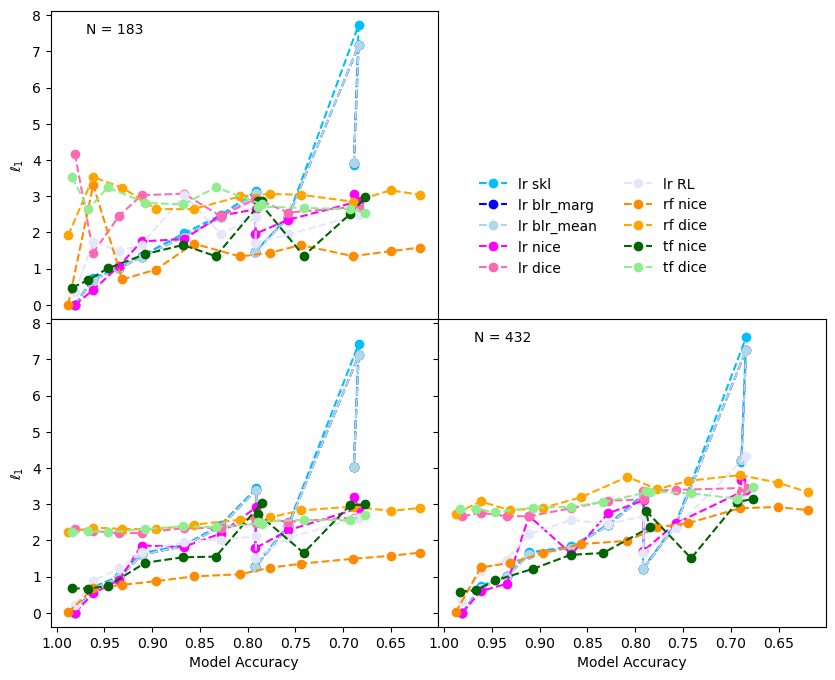

In [14]:
#fig, axes = plt.subplots(2, 2, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 1], 'width_ratios': [1, 1]})
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
(ax_top, _), (ax_bottom_left, ax_bottom_right) = axes

# Remove the top-right plot
fig.delaxes(axes[0, 1])  # This removes the top-right subplot

# fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)
# ax_top, (ax_bottom_left, ax_bottom_right) = axes[0], axes[1].subplots(1, 2, sharex=True, sharey=True)

for i, kk in enumerate(cf_methods):
    x_acc = []
    d2 = []
    compl = {}

    for k in cf_results_dict:
        if k == 'noise_0': continue
        ii = int(k.split("_")[-1])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]

        if kk[1] in ['nice', 'dice', 'RL'] and kk[0] != 'tf':
            A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)

        good_indices = cfs_good_indices[k][kk]

        # Default: Original Selection
        d_temp = get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=l_order)
        if len(d_temp) > 0:
            d2.append(d_temp)
            compl[(kk, k)] = (sum(good_indices) / len(good_indices))
            x_acc.append(model_results_dict[k][(kk[0], 'accuracy')])

    d2 = np.array([np.array([np.mean(i), np.percentile(i, 25), np.percentile(i, 75)]) for i in d2])

    if len(d2) == 0:
        continue

    # -----------------------------
    # Top Plot (False Negatives - FN) with good_indices
    # -----------------------------
    x_acc_fn = []
    d2_fn = []
    for k in cf_results_dict:
        if k == 'noise_0': continue
        ii = int(k.split("_")[-1])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]

        if kk[1] in ['nice', 'dice', 'RL'] and kk[0] != 'tf':
            A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)

        fn_indices = (cf_calc[ii-1].cm_data['blr'] == 'FN') #& good_indices
        d_temp_fn = get_distance(A[fn_indices], B[fn_indices], numerical_columns, categorical_columns, l_norm=l_order)

        if len(d_temp_fn) > 0:
            d2_fn.append(d_temp_fn)
            x_acc_fn.append(model_results_dict[k][(kk[0], 'accuracy')])

    d2_fn = np.array([np.array([np.mean(i), np.percentile(i, 25), np.percentile(i, 75)]) for i in d2_fn])

    if len(d2_fn) > 0:
        if any(value < 0.9 for value in compl.values()):
            pass
        else:
            ax_top.plot(x_acc_fn, d2_fn[:, 0], color=colours[kk], label=kk[0] + ' ' + kk[1], alpha=1, linestyle='--', marker='o')

    if kk[1]=='skl':
        ax_top.text(
            -1.1, 1.85, 'N = ' + str(fn_indices.sum()), #fontsize=12, 
            verticalalignment='top', horizontalalignment='left', transform=ax.transAxes)

    # -----------------------------
    # Bottom-Right Plot (True Negatives - TN) with good_indices
    # -----------------------------
    x_acc_tn = []
    d2_tn = []
    for k in cf_results_dict:
        if k == 'noise_0': continue
        ii = int(k.split("_")[-1])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]

        if kk[1] in ['nice', 'dice', 'RL'] and kk[0] != 'tf':
            A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)

        tn_indices = (cf_calc[ii-1].cm_data['blr'] == 'TN') #& good_indices
        d_temp_tn = get_distance(A[tn_indices], B[tn_indices], numerical_columns, categorical_columns, l_norm=l_order)

        if len(d_temp_tn) > 0:
            d2_tn.append(d_temp_tn)
            x_acc_tn.append(model_results_dict[k][(kk[0], 'accuracy')])

    d2_tn = np.array([np.array([np.mean(i), np.percentile(i, 25), np.percentile(i, 75)]) for i in d2_tn])

    if len(d2_tn) > 0:
        if any(value < 0.9 for value in compl.values()):
            pass
        else:
            ax_bottom_right.plot(x_acc_tn, d2_tn[:, 0], color=colours[kk], label=kk[0] + ' ' + kk[1], alpha=1, linestyle='--', marker='o')
    
    if kk[1]=='skl':
        ax_bottom_right.text(
            -0.1, 0.85, 'N = ' + str(tn_indices.sum()), #fontsize=12, 
            verticalalignment='top', horizontalalignment='left', transform=ax.transAxes)

    #ax_bottom_right.legend(frameon=False, loc='lower right')
    ax_bottom_right.legend(loc="upper center", bbox_to_anchor=(0.4, 1.5), ncol=2, frameon=False)


    # -----------------------------
    # Standard Plot (Bottom-Left)
    # -----------------------------
    if any(value < 0.9 for value in compl.values()):
        pass
    else:
        ax_bottom_left.plot(x_acc, d2[:, 0], color=colours[kk], label=kk[0] + ' ' + kk[1], alpha=1, linestyle='--', marker='o')

# Formatting plots
for ax in [ax_top, ax_bottom_left, ax_bottom_right]:
    ax.set_xlabel('Model Accuracy')
    ax.invert_xaxis()

ax_top.set_ylabel(r'$\ell_1$')
ax_bottom_left.set_ylabel(r'$\ell_1$ ')

fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero

In [18]:
cf_calc[0].counterfactual_results[('lr','skl')]

array([[ 2.33680427,  0.10134679],
       [-0.31562246,  0.48945223],
       [ 0.72997337,  0.33680504],
       ...,
       [-0.97787021,  0.58669823],
       [-0.68835322,  0.54433584],
       [ 0.27347613,  0.40360012]])

In [16]:
dir(cf_calc[0])

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'cat_cols_tf',
 'cat_feat',
 'check_cfs',
 'clf_lr',
 'clf_lr_np',
 'clf_rf',
 'clf_rf_np',
 'cm_data',
 'cms',
 'counterfactual_results',
 'df_test',
 'df_test_const',
 'df_test_tf',
 'df_train',
 'df_train_tf',
 'do_dice',
 'do_marg',
 'get_cfs',
 'get_models',
 'good_cf_indices',
 'groups',
 'min_frequency',
 'model',
 'model_stats',
 'models',
 'num_cols_tf',
 'num_feat',
 'polytopes',
 'samples',
 'y_test',
 'y_train']